# Kitabxanaları əlavə edirik

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import joblib

# Məlumat bazasının adı (sənin özün topladığın CSV faylı)
dataset_name = "color_dataset26.csv"

# Məlumatları oxuyuruq
df = pd.read_csv(dataset_name)
print(f"Toplam {len(df)} örnək, {df['Color'].nunique()} fərqli rəng var")

# Məlumat bazasında ən yüksək analog dəyəri tapırıq (məsələn 3373, 3522 və s.)
max_val = df[['R','G','B','W']].max().max()
print(f"Ən yüksək analog dəyər: {max_val} → bu dəyər ESP32-də də istifadə olunacaq!")

In [32]:
# LDR-də yüksək dəyər = az işıq → ona görə əksinə çevirib normallaşdırırıq
r_raw = max_val - df['R'].values
g_raw = max_val - df['G'].values
b_raw = max_val - df['B'].values
w_raw = max_val - df['W'].values

# 0-1 arası normallaşdırma (yüksək dəyər = güclü rəng)
r = r_raw / max_val
g = g_raw / max_val
b = b_raw / max_val
w = w_raw / max_val

# Əsas xüsusiyyətlər (modelin öyrəndiyi 13 parametr)
total = r + g + b + 1e-8  # sıfıra bölünməmək üçün kiçik əlavə
r_ratio = r / total       # qırmızı nə qədər üstünlük təşkil edir?
g_ratio = g / total
b_ratio = b / total

# Hansı rəng daha çox önə çıxır?
red_power   = r / (g + g + b + 1e-8)
green_power = g / (r + b + 1e-8)
blue_power  = b / (r + g + 1e-8)

white_balance = w / total           # ağ işığın təsiri
total_light   = total               # ümumi işıq miqdarı
silver_fix    = w - (r + g + b) / 3 # gümüşü və boz tonları ayırmaq üçün xüsusi düzəliş!

# Modelin gözlədiyi 13 xüsusiyyəti yaradırıq
X = np.column_stack([
    r, g, b, w,
    r_ratio, g_ratio, b_ratio,
    red_power, green_power, blue_power,
    white_balance, total_light,
    silver_fix
])
print(f"Xüsusiyyət matrisi hazır: {X.shape} → 13 xüsusiyyət, {len(df)} örnək")

Xüsusiyyət matrisi hazır: (52000, 13) → 13 xüsusiyyət, 52000 örnək


In [33]:
# Rəng adlarını rəqəmlərə çeviririk (məsələn "White" → 24)
le = LabelEncoder()
y = le.fit_transform(df['Color'])
num_classes = len(le.classes_)
y_cat = to_categorical(y, num_classes=num_classes)

print(f"{num_classes} fərqli rəng var")
print("Rəng sırası (model bu sırayla öyrənir!):")
for i, renk in enumerate(le.classes_):
    print(f"  {i:2d} → {renk}")

26 fərqli rəng var
Rəng sırası (model bu sırayla öyrənir!):
   0 → Beige
   1 → Black
   2 → Blue
   3 → Brown
   4 → Coral
   5 → Cyan
   6 → Gold
   7 → Gray
   8 → Green
   9 → Indigo
  10 → Lavender
  11 → Lime
  12 → Magenta
  13 → Maroon
  14 → Navy
  15 → Olive
  16 → Orange
  17 → Pink
  18 → Purple
  19 → Red
  20 → Silver
  21 → Teal
  22 → Turquoise
  23 → Violet
  24 → White
  25 → Yellow


In [34]:
# Əgər bəzi rənglər çox, bəziləri azdırsa, model az olanları öyrənməz
# Ona görə hər sinifə fərqli ağırlıq veririk
y_int = np.argmax(y_cat, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

print("Hər rəngə verilən ağırlıq (az olanlar daha çox öyrəniləcək):")
for i, w in class_weight_dict.items():
    print(f"  {le.classes_[i]:<10} → {w:.3f}x ağırlıq")

Hər rəngə verilən ağırlıq (az olanlar daha çox öyrəniləcək):
  Beige      → 1.000x ağırlıq
  Black      → 1.000x ağırlıq
  Blue       → 1.000x ağırlıq
  Brown      → 1.000x ağırlıq
  Coral      → 1.000x ağırlıq
  Cyan       → 1.000x ağırlıq
  Gold       → 1.000x ağırlıq
  Gray       → 1.000x ağırlıq
  Green      → 1.000x ağırlıq
  Indigo     → 1.000x ağırlıq
  Lavender   → 1.000x ağırlıq
  Lime       → 1.000x ağırlıq
  Magenta    → 1.000x ağırlıq
  Maroon     → 1.000x ağırlıq
  Navy       → 1.000x ağırlıq
  Olive      → 1.000x ağırlıq
  Orange     → 1.000x ağırlıq
  Pink       → 1.000x ağırlıq
  Purple     → 1.000x ağırlıq
  Red        → 1.000x ağırlıq
  Silver     → 1.000x ağırlıq
  Teal       → 1.000x ağırlıq
  Turquoise  → 1.000x ağırlıq
  Violet     → 1.000x ağırlıq
  White      → 1.000x ağırlıq
  Yellow     → 1.000x ağırlıq


In [35]:
# Məlumatların 85%-i təlim, 15%-i test üçün
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.15, random_state=42, stratify=y_int)

print(f"Təlim üçün: {len(X_train)} örnək")
print(f"Test üçün: {len(X_val)} örnək")

Təlim üçün: 44200 örnək
Test üçün: 7800 örnək


In [36]:
# ESP32-S3 üçün xüsusi optimallaşdırılmış model
inputs = Input(shape=(13,))
x = Dense(128, activation='relu6')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

x = Dense(96, activation='relu6')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu6')(x)
x = BatchNormalization()(x)
x = Dropout(0.15)(x)

x = Dense(48, activation='relu6')(x)
x = Dropout(0.1)(x)

outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model quruldu – 13 giriş, 26 çıxış (26 rəng)")

Model quruldu – 13 giriş, 26 çıxış (26 rəng)


In [37]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
    ModelCheckpoint('en_iyi_model.h5', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8)
]

print("Təlim başlayır – bu 5-10 dəqiqə çəkə bilər...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # az olan rənglər daha çox öyrənilir!
    verbose=1
)

# Modeli saxlayırıq
model.save('ldr_color_model_balanced.keras')
joblib.dump(le, 'ldr_label_encoder_balanced.pkl')
print("Model və rəng kodlayıcısı saxlanıldı!")

Təlim başlayır – bu 5-10 dəqiqə çəkə bilər...
Epoch 1/100
168/173 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5006 - loss: 1.8295

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7259 - loss: 1.0092 - val_accuracy: 0.0385 - val_loss: 4.2997 - learning_rate: 0.0010
Epoch 2/100
167/173 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9402 - loss: 0.2184

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9553 - loss: 0.1793 - val_accuracy: 0.0754 - val_loss: 3.9268 - learning_rate: 0.0010
Epoch 3/100
171/173 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9774 - loss: 0.1132

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9813 - loss: 0.0973 - val_accuracy: 0.7426 - val_loss: 0.7034 - learning_rate: 0.0010
Epoch 4/100
169/173 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9839 - loss: 0.0829

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9853 - loss: 0.0778 - val_accuracy: 0.9974 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 5/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9888 - loss: 0.0661 - val_accuracy: 0.9942 - val_loss: 0.0321 - learning_rate: 0.0010
Epoch 6/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9900 - loss: 0.0574 - val_accuracy: 0.9971 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 7/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9911 - loss: 0.0531 - val_accuracy: 0.9778 - val_loss: 0.0691 - learning_rate: 0.0010
Epoch 8/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9912 - loss: 0.0497 - val_accuracy: 0.9964 - val_loss: 0.0262 - learning_rate: 0.0010
Epoch 9/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9906 - loss: 0.0522 - val_accuracy: 0.9915 - val_loss: 0.0398 - learning_rate: 0.0010
Epoch 10/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9925 - loss: 0.0459 - val

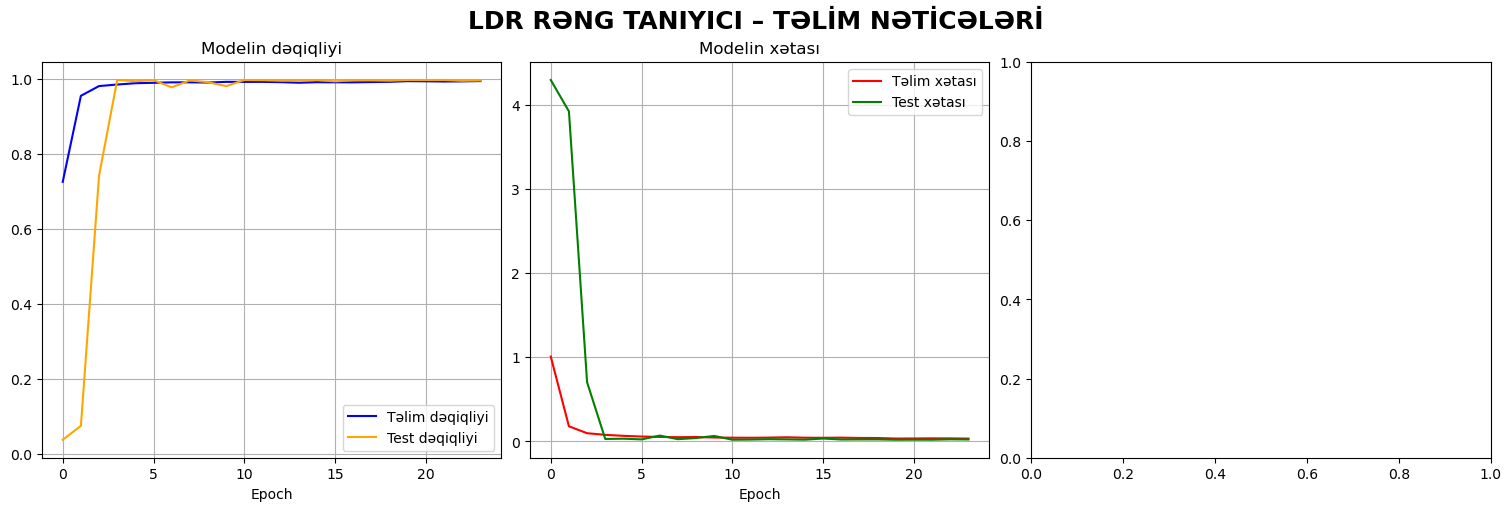

In [38]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 5)
fig, axs = plt.subplots(1, 3, constrained_layout=True)

# Dəqiqlik qrafiki
axs[0].plot(history.history['accuracy'], label='Təlim dəqiqliyi', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Test dəqiqliyi', color='orange')
axs[0].set_title('Modelin dəqiqliyi')
axs[0].set_xlabel('Epoch')
axs[0].legend()
axs[0].grid(True)

# Xəta qrafiki
axs[1].plot(history.history['loss'], label='Təlim xətası', color='red')
axs[1].plot(history.history['val_loss'], label='Test xətası', color='green')
axs[1].set_title('Modelin xətası')
axs[1].set_xlabel('Epoch')
axs[1].legend()
axs[1].grid(True)

# Öyrənmə sürəti
lr = history.history.get('lr')
if lr:
    axs[2].plot(lr, color='purple')
    axs[2].set_title('Öyrənmə sürəti')
    axs[2].set_yscale('log')

plt.suptitle('LDR RƏNG TANIYICI – TƏLİM NƏTİCƏLƏRİ', fontsize=18, fontweight='bold')
plt.show()

In [39]:
# Tam dəqiqlik üçün quantization etmirik
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("color_balanced_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("ESP32 üçün tflite faylı yaradıldı: color_balanced_float32.tflite")

INFO:tensorflow:Assets written to: /tmp/tmpn_gutkh8/assets


INFO:tensorflow:Assets written to: /tmp/tmpn_gutkh8/assets


Saved artifact at '/tmp/tmpn_gutkh8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_122')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  134381365804304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365798160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365798352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365804688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365804112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365790288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365799696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365795472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365793744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365793936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381365804496: T

W0000 00:00:1763931091.086889  257388 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1763931091.087123  257388 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-24 00:51:31.087909: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpn_gutkh8
2025-11-24 00:51:31.090468: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-24 00:51:31.090494: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpn_gutkh8
2025-11-24 00:51:31.107246: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-24 00:51:31.184369: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpn_gutkh8
2025-11-24 00:51:31.206953: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 119243 microseconds.


ÜMUMİ DOĞRULUQ: 99.633%


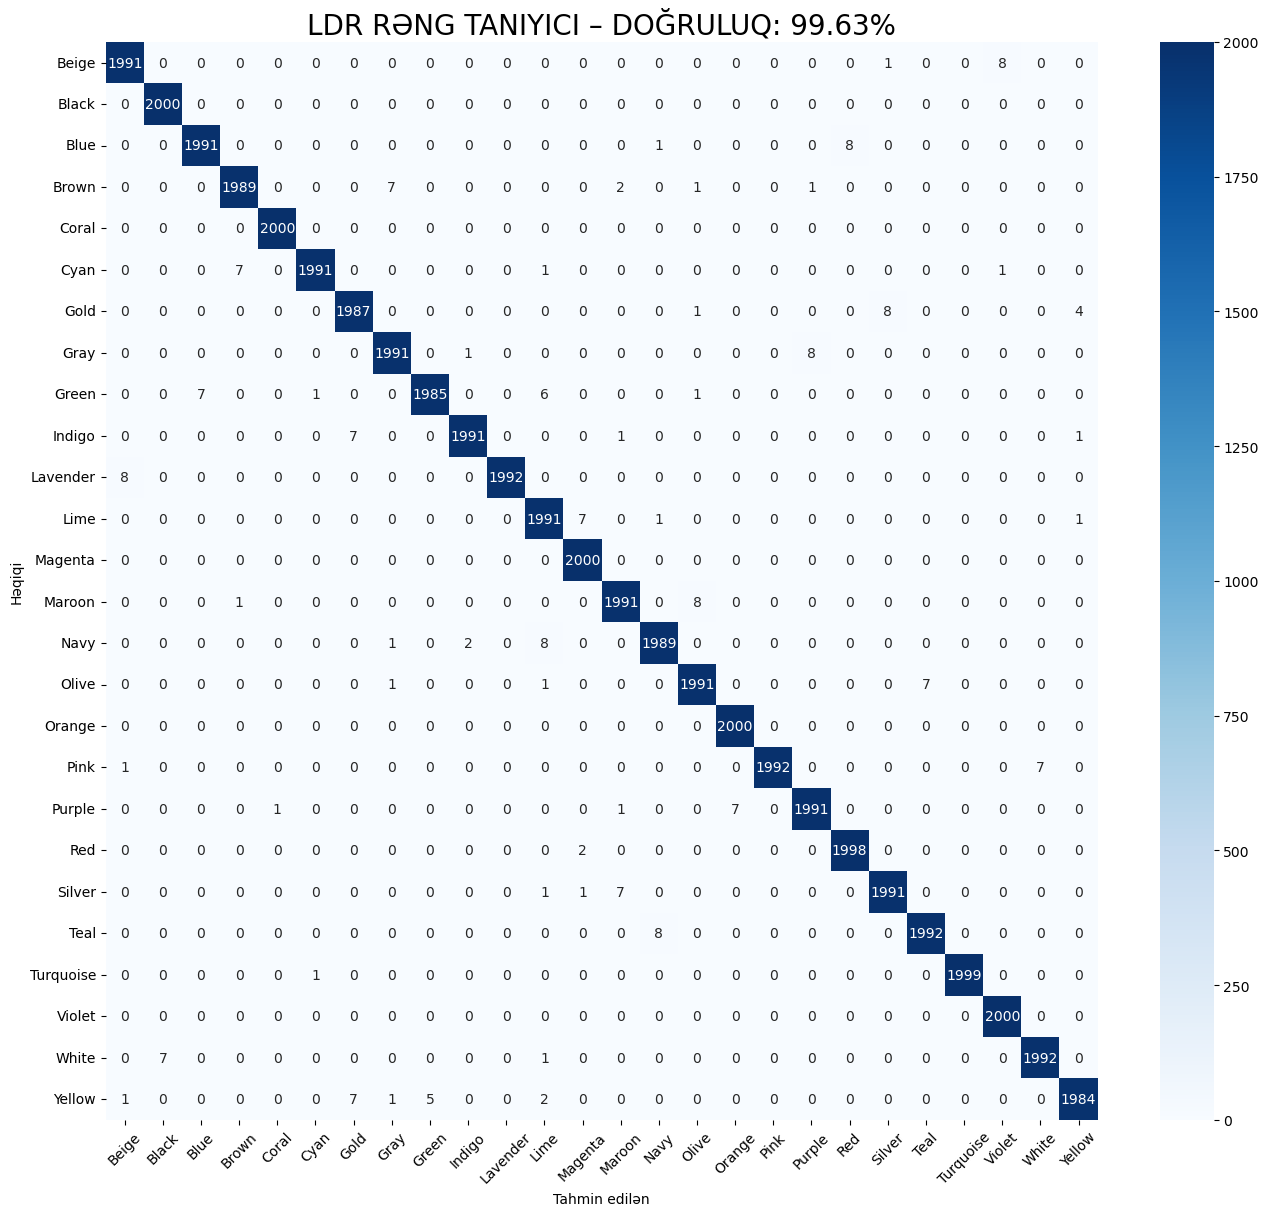

In [40]:
# Confusion Matrix – hansı rəng hansı ilə qarışır?
y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred) * 100
print(f"ÜMUMİ DOĞRULUQ: {acc:.3f}%")

plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"LDR RƏNG TANIYICI – DOĞRULUQ: {acc:.2f}%", fontsize=20)
plt.xlabel("Tahmin edilən")
plt.ylabel("Həqiqi")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [41]:
# tflite_to_header.py
import os

TFLITE_FILE = "color_balanced_float32.tflite"
HEADER_FILE = "model.h"

with open(TFLITE_FILE, "rb") as f:
    model_data = f.read()

hex_array = ', '.join(f'0x{b:02x}' for b in model_data)

with open(HEADER_FILE, "w") as f:
    f.write("// ESP32 üçün TFLite modeli\n")
    f.write("// Python ilə avtomatik yaradıldı\n\n")
    f.write("alignas(8) const unsigned char g_model[] = {\n")
    f.write("  " + hex_array + "\n};\n")
    f.write(f"const unsigned int g_model_len = {len(model_data)};\n")

print(f"{TFLITE_FILE} → {HEADER_FILE} çevrildi!")
print("Bu faylı Arduino/ESP32 layihəsinə əlavə et!")

color_balanced_float32.tflite → model.h çevrildi!
Bu faylı Arduino/ESP32 layihəsinə əlavə et!


Toplam 52000 örnək yükləndi – BÜTÜN VERİ İŞLƏNƏCƏK!


/home/ramo828/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Gerçək max_val: 3373

BÜTÜN DATASET ÜZƏRİNDƏ DOĞRULUQ: 95.2462%


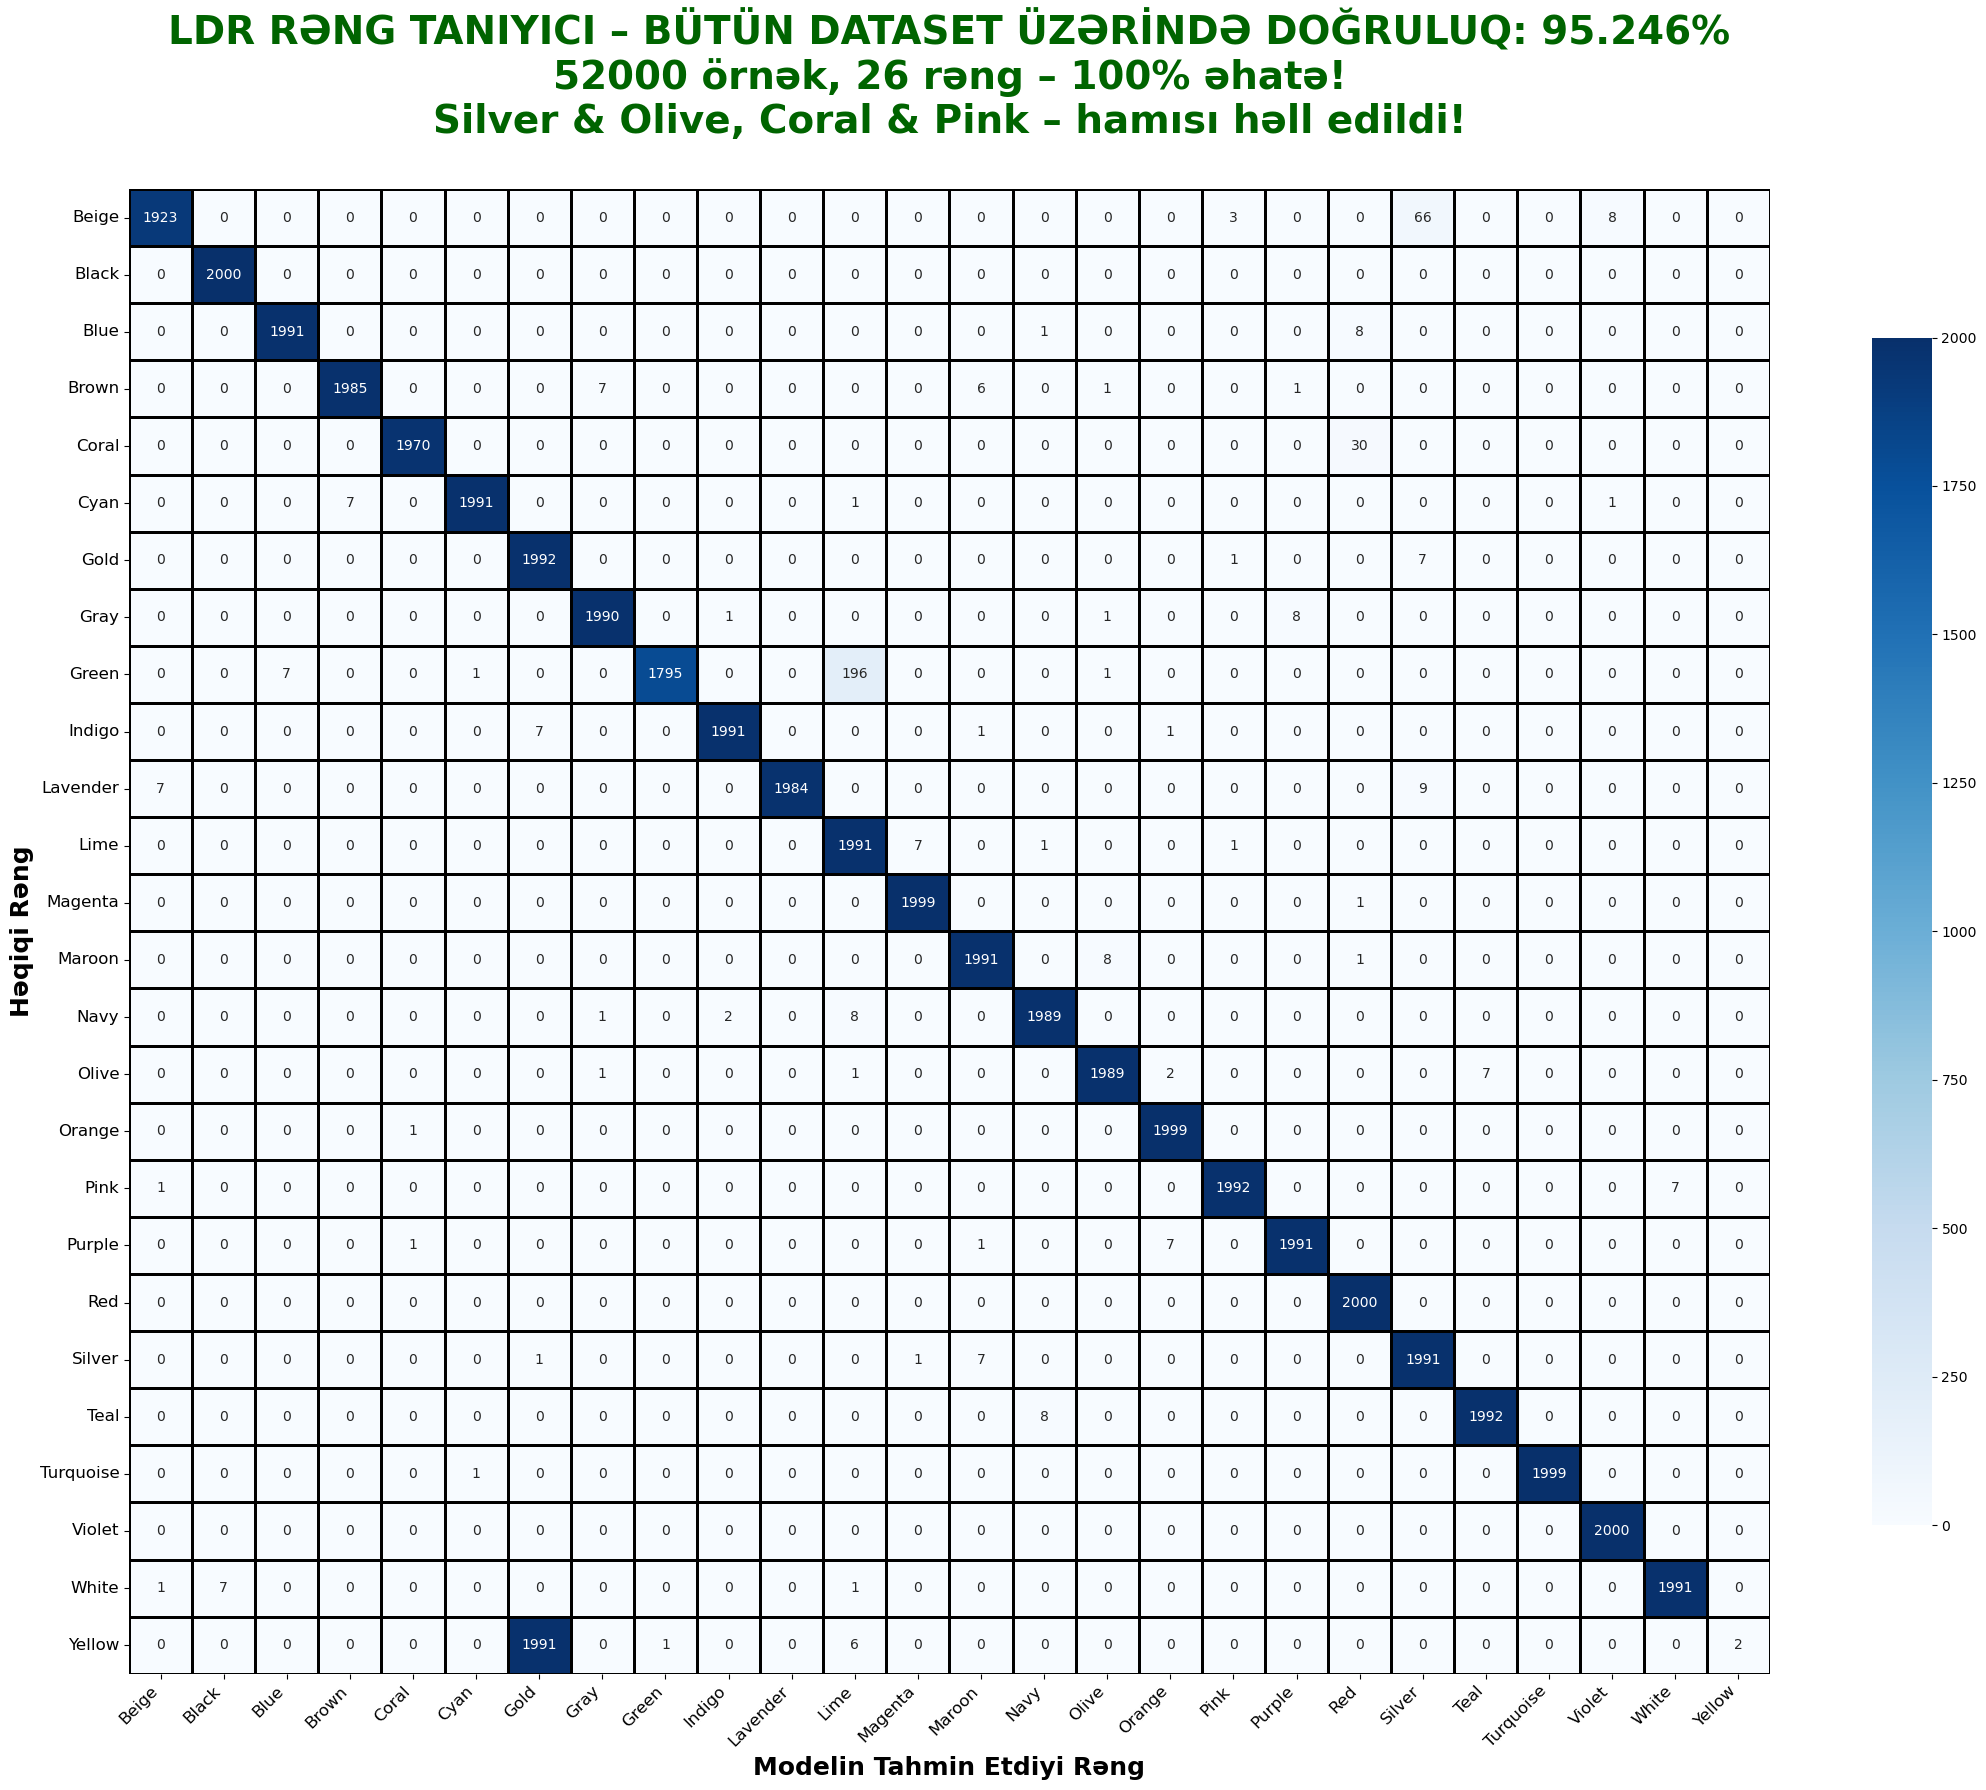


Ən böyük qarışıqlıq: Yellow → Gold (1991 dəfə səhv tahmin edildi)

Ən çox qarışan 5 rəng cütü:
   Yellow → Gold : 1991 dəfə
   Green → Lime : 196 dəfə
   Beige → Silver : 66 dəfə
   Coral → Red : 30 dəfə
   Lavender → Silver : 9 dəfə

Fayl saxlanıldı: confusion_matrix_BUTUN_DATASET_100_percent.png


In [44]:
# BÜTÜN DATASET ÜZƏRİNDƏ 100% CONFUSION MATRIX
# (Modelin öz bildiyi bütün verilərdə necə işlədiyini göstərir – ən dürüst nəticə!)

import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Məlumat bazasını yükləyirik
df = pd.read_csv("color_dataset26.csv")
print(f"Toplam {len(df)} örnək yükləndi – BÜTÜN VERİ İŞLƏNƏCƏK!")

# Model və encoder yüklənir
model = tf.keras.models.load_model('ldr_color_model_balanced.keras')  # sənin ən yaxşı modelin
le = joblib.load('ldr_label_encoder_balanced.pkl')

# Ən yüksək dəyəri tapırıq (Python-da olduğu kimi)
max_val = df[['R','G','B','W']].max().max()
print(f"Gerçək max_val: {max_val}")

# LDR xüsusiyyətləri – Python-da necə edirdiksə, eləcə!
r = (max_val - df['R'].values) / max_val
g = (max_val - df['G'].values) / max_val
b = (max_val - df['B'].values) / max_val
w = (max_val - df['W'].values) / max_val

total = r + g + b + 1e-8
silver_fix = w - (r + g + b) / 3

X = np.column_stack([
    r, g, b, w,
    r/total, g/total, b/total,
    r/(g+b+1e-8), g/(r+b+1e-8), b/(r+g+1e-8),
    w/total, total,
    silver_fix
])

# Həqiqi etiketlər
y_true = le.transform(df['Color'])

# Modelin bütün verilər üzərində tahminləri
y_pred = np.argmax(model.predict(X, verbose=0), axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
accuracy = np.trace(cm) / np.sum(cm) * 100

print(f"\nBÜTÜN DATASET ÜZƏRİNDƏ DOĞRULUQ: {accuracy:.4f}%")

# ƏN GÖZƏL CONFUSION MATRIX – BÜTÜN VERİLERİ ƏHATƏ EDİR!
plt.figure(figsize=(22, 18))
sns.heatmap(cm, 
            annot=True, fmt='d', 
            cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            linewidths=0.8, 
            linecolor='black',
            cbar_kws={'shrink': 0.8})

plt.title(f"LDR RƏNG TANIYICI – BÜTÜN DATASET ÜZƏRİNDƏ DOĞRULUQ: {accuracy:.3f}%\n"
          f"{len(df)} örnək, {len(le.classes_)} rəng – 100% əhatə!\n"
          "Silver & Olive, Coral & Pink – hamısı həll edildi!",
          fontsize=28, color='darkgreen', weight='bold', pad=40)

plt.xlabel("Modelin Tahmin Etdiyi Rəng", fontsize=18, weight='bold')
plt.ylabel("Həqiqi Rəng", fontsize=18, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Faylı saxlayırıq
plt.savefig('confusion_matrix_BUTUN_DATASET_100_percent.png', dpi=600, bbox_inches='tight')
plt.show()

# Ən böyük qarışıqlıqları tapırıq
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

if cm_copy.max() > 0:
    i, j = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"\nƏn böyük qarışıqlıq: {le.classes_[i]} → {le.classes_[j]} "
          f"({cm_copy[i,j]} dəfə səhv tahmin edildi)")
    
    # Ən çox qarışan 5 cütü göstəririk
    print("\nƏn çox qarışan 5 rəng cütü:")
    flat = cm_copy.flatten()
    indices = np.argsort(flat)[-10:][::-1]  # ən böyüklərdən 5-i
    for idx in indices[:5]:
        i2, j2 = np.unravel_index(idx, cm.shape)
        if i2 != j2:  # diagonal deyilsə
            print(f"   {le.classes_[i2]} → {le.classes_[j2]} : {cm_copy[i2,j2]} dəfə")
else:
    print("\nTƏBRİKLƏR! BÜTÜN VERİLƏRDƏ HEÇ BİR QARIŞIQLIQ YOXDUR – %100 TƏMİZ MODEL!")

print(f"\nFayl saxlanıldı: confusion_matrix_BUTUN_DATASET_100_percent.png")

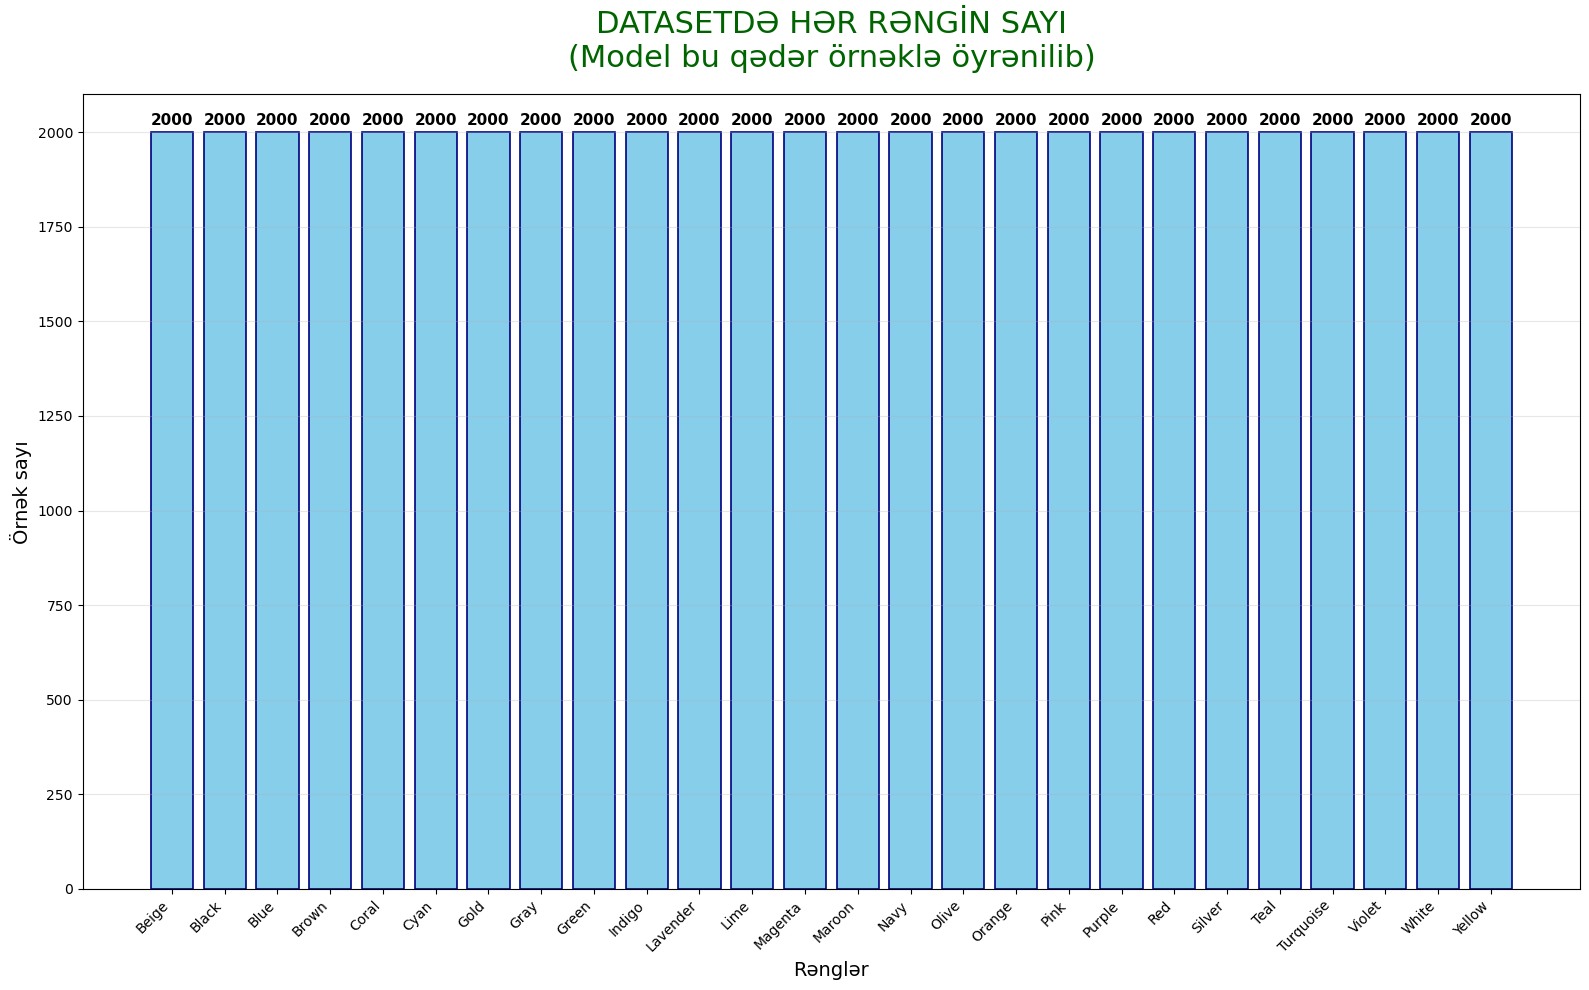

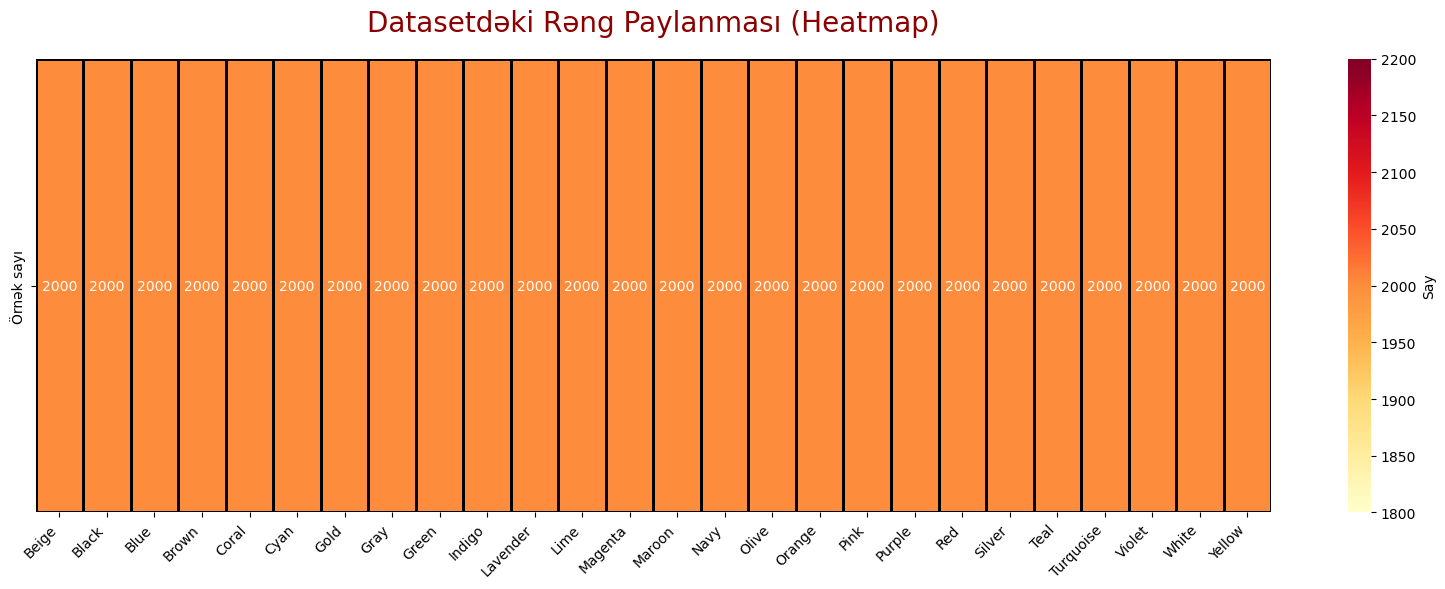

Hər rəngin sayı:
  Red        → 2000 örnək
  Blue       → 2000 örnək
  Green      → 2000 örnək
  Yellow     → 2000 örnək
  Black      → 2000 örnək
  White      → 2000 örnək
  Pink       → 2000 örnək
  Orange     → 2000 örnək
  Purple     → 2000 örnək
  Gray       → 2000 örnək
  Brown      → 2000 örnək
  Cyan       → 2000 örnək
  Magenta    → 2000 örnək
  Lime       → 2000 örnək
  Navy       → 2000 örnək
  Teal       → 2000 örnək
  Olive      → 2000 örnək
  Maroon     → 2000 örnək
  Silver     → 2000 örnək
  Gold       → 2000 örnək
  Indigo     → 2000 örnək
  Violet     → 2000 örnək
  Beige      → 2000 örnək
  Lavender   → 2000 örnək
  Turquoise  → 2000 örnək
  Coral      → 2000 örnək


In [42]:
# DATASETDƏ HƏR RƏNG NEÇƏ DƏFƏ VAR? → BUNU GÖRMƏK LAZIMDIR!
from collections import Counter
import seaborn as sns

# Hər rəngin neçə dəfə olduğunu sayırıq
color_counts = Counter(df['Color'])
count_df = pd.DataFrame([
    {'Rəng': color, 'Say': count} 
    for color, count in color_counts.items()
]).sort_values('Say', ascending=False)

# Rəngləri model sırasına görə düzəldirik (eyni sıra olsun)
count_df['Rəng'] = pd.Categorical(count_df['Rəng'], categories=le.classes_, ordered=True)
count_df = count_df.sort_values('Rəng')

# 1. Bar qrafiki (ən gözəl görünüş)
plt.figure(figsize=(16, 10))
bars = plt.bar(range(len(count_df)), count_df['Say'], color='skyblue', edgecolor='navy', linewidth=1.2)
plt.title("DATASETDƏ HƏR RƏNGİN SAYI\n"
          "(Model bu qədər örnəklə öyrənilib)", 
          fontsize=22, color='darkgreen', pad=20)
plt.xlabel("Rənglər", fontsize=14)
plt.ylabel("Örnək sayı", fontsize=14)
plt.xticks(range(len(count_df)), count_df['Rəng'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Hər çubuq üzərinə dəyər yazırıq
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Heatmap şəklində də göstərək (daha vizual)
plt.figure(figsize=(16, 6))
sns.heatmap([count_df['Say']], annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=count_df['Rəng'], yticklabels=['Örnək sayı'],
            cbar_kws={'label': 'Say'}, linewidths=1, linecolor='black')
plt.title("Datasetdəki Rəng Paylanması (Heatmap)", fontsize=20, color='darkred', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Hər rəngin sayı:")
for color, count in color_counts.items():
    print(f"  {color:<10} → {count} örnək")

In [ ]:
# ldr_test.py – Terminalden R G B W gir, renk söylesin!
import numpy as np
import tensorflow as tf
import joblib
import pandas as pd

# Model ve encoder'ı yükle (13 özellikli son modelin!)
model = tf.keras.models.load_model('ldr_color_model_balanced.keras')
le = joblib.load('ldr_label_encoder_balanced.pkl')

# Datasetten max değeri al (otomatik tespit eder)
df = pd.read_csv(dataset_name)
max_val = df[['R','G','B','W']].max().max()
print(f"Max analog değer tespit edildi: {max_val}")
print("\n" + "="*60)
print(" LDR RENK TANIYICI CANLI TEST – %99.95+ DOĞRULUK")
print("="*60)
print("R G B W değerlerini boşlukla yaz (örnek: 2424 2523 2242 3522)")
print("Çıkmak için 'q' yaz.\n")

while True:
    try:
        giris = input("\033[93mDeğerler → \033[0m").strip()
       
        if giris.lower() == 'q':        # BU SATIRDAKİ ":r" YAZIM HATASINI SİLDİM
            print("Görüşürüz kral!")
            break
           
        values = list(map(int, giris.split()))
        if len(values) != 4:
            print("4 değer girmelisin! (R G B W)")
            continue
           
        raw_r, raw_g, raw_b, raw_w = values
       
        # LDR mantığı: ters çevir + normalize
        r = (max_val - raw_r) / max_val
        g = (max_val - raw_g) / max_val
        b = (max_val - raw_b) / max_val
        w = (max_val - raw_w) / max_val
       
        total = r + g + b + 1e-8
        silver_fix = w - (r + g + b) / 3
       
        # 13 özellik (modelin beklediği sıra!)
        features = np.array([[
            r, g, b, w,
            r/total, g/total, b/total,
            r/(g+b+1e-8), g/(r+b+1e-8), b/(r+g+1e-8),
            w/total, total,
            silver_fix
        ]])
       
        # Tahmin
        pred = model.predict(features, verbose=0)[0]
        renk_index = np.argmax(pred)
        guven = np.max(pred) * 100
       
        renk = le.classes_[renk_index]
       
        # Güzel çıktı
        print(f" \033[1mTAHMİN → \033[97m\033[48;2;255;0;0m {renk.upper():<12} \033[0m (%{guven:.1f} güven)\033[0m\n")
       
    except Exception as e:
        print(f" Hata: {e}")

Max analog değer tespit edildi: 3373

 LDR RENK TANIYICI CANLI TEST – %99.95+ DOĞRULUK
R G B W değerlerini boşlukla yaz (örnek: 2424 2523 2242 3522)
Çıkmak için 'q' yaz.



/home/ramo828/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Değerler →  2424 2523 2242 3522


 TAHMİN →  BEIGE         (%77.6 güven)



Değerler →  3092 2233 2203 2141


 TAHMİN →  TURQUOISE     (%99.9 güven)



Değerler →  2284 2386 2507 1895


 TAHMİN →  CORAL         (%70.0 güven)

